# 第303章: 潜在走査（Latent Traversal）

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 潜在走査（Latent Traversal）の概念と目的を説明できる
- [ ] 潜在空間の各次元を1つずつ変化させ、その意味を発見できる
- [ ] 次元ごとの変化をGIFアニメーションとして生成できる
- [ ] 「もつれた（entangled）」次元と「解きほぐされた（disentangled）」次元の違いを識別できる

## 🎯 前提知識

- ✅ Notebook 300-302（潜在空間の基礎、探索、ベクトル演算）
- ✅ Notebook 37-38（VAE理論と実装）

⏱️ **推定学習時間**: 60-90分
📊 **難易度**: ★★★☆☆（中級）
🎓 **カテゴリ**: 基礎・分析

---

## 🌟 はじめに

前章では「太さ」や「傾き」の方向を手動で発見しました。
この章では、より体系的なアプローチ — **潜在走査（Latent Traversal）** — を学びます。

### 🤔 潜在走査とは？

潜在コード z の**1つの次元だけ**を値を変化させ、
他の次元は固定したまま、生成される画像の変化を観察する手法です。

```
  潜在コード z = [z₁, z₂, z₃, ..., z₁₀]

  z₁方向の走査:
  z = [-3, z₂, z₃, ...] → [-2, z₂, z₃, ...] → ... → [3, z₂, z₃, ...]
       ↓                     ↓                          ↓
     画像1               画像2                       画像N

  → z₁が「何を」制御しているか観察できる！
```

### 📝 この章の構成

1. **単一次元の走査** — 各次元がどんな変化を制御するか発見
2. **全次元の走査マップ** — 10次元すべてを一覧表示
3. **異なる数字での走査** — 同じ次元が数字ごとに何を意味するか
4. **GIFアニメーション生成** — 走査結果をアニメーション化
5. **もつれの問題** — なぜ1次元で複数の属性が変わるのか

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.animation as animation
from IPython.display import HTML, Image as IPImage
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import warnings, os

warnings.filterwarnings('ignore')

def setup_japanese_font():
    japanese_fonts = ['Hiragino Sans', 'Yu Gothic', 'MS Gothic', 'Noto Sans CJK JP', 'IPAexGothic']
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

print(f"日本語フォント: {font_used}")
print(f"Device: {device}")
print("✅ 環境設定完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


日本語フォント: Yu Gothic
Device: cpu
✅ 環境設定完了


In [2]:
# ============================================================
# VAEの学習（302と同様、潜在次元=10）
# ============================================================

class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("VAE (z=10) の学習...")
for epoch in range(2):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)
        recon, mu, logvar = model(x)
        loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum') \
               - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20 | Loss: {total_loss/len(train_dataset):.2f}")

# テストデータのエンコード
model.eval()
all_z, all_labels, all_images = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model.encode(x.view(-1, 784).to(device))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())
        all_images.append(x.numpy())

all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)
all_images = np.concatenate(all_images)
digit_indices = {d: np.where(all_labels == d)[0] for d in range(10)}

print("✅ 学習・エンコード完了")

VAE (z=10) の学習...
✅ 学習・エンコード完了


---

## 1. 単一次元の走査

まず、ある画像の潜在コードを取り、**1つの次元だけ**を -3 から +3 まで変化させてみましょう。

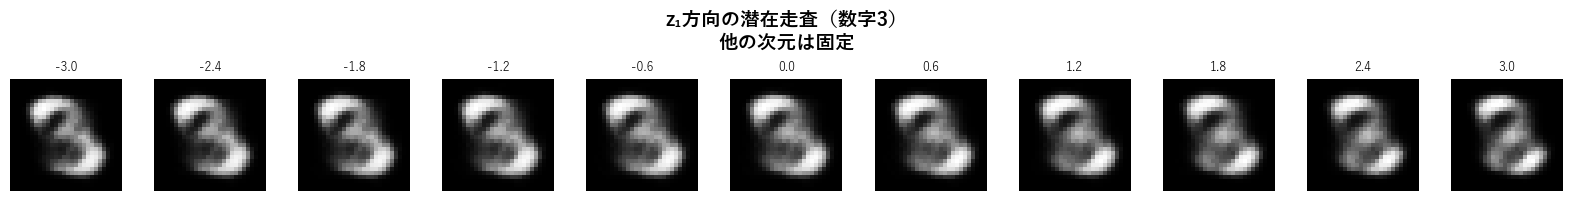

💡 z₁を動かすと、数字のどんな属性が変わるか観察してください
   形状？太さ？傾き？それとも数字の種類？


In [3]:
# ============================================================
# 単一次元の走査: 数字3を例に
# ============================================================

def decode_z(z_vec):
    with torch.no_grad():
        z_t = torch.tensor(z_vec, dtype=torch.float32).unsqueeze(0).to(device)
        return model.decode(z_t).cpu().numpy().reshape(28, 28)

# 数字3のサンプルを1つ選択
base_idx = digit_indices[3][0]
z_base = all_z[base_idx].copy()

# z₁方向の走査
n_steps = 11
z_range = np.linspace(-3, 3, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(16, 2))

for i, val in enumerate(z_range):
    z_mod = z_base.copy()
    z_mod[0] = val  # z₁のみ変更
    img = decode_z(z_mod)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'{val:.1f}', fontsize=9)

fig.suptitle(f'z₁方向の潜在走査（数字3）\n他の次元は固定', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_303_01_single_traversal.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 z₁を動かすと、数字のどんな属性が変わるか観察してください")
print("   形状？太さ？傾き？それとも数字の種類？")

---

## 2. 全次元の走査マップ

10次元すべてを一覧表示して、各次元が何を制御しているか発見しましょう。

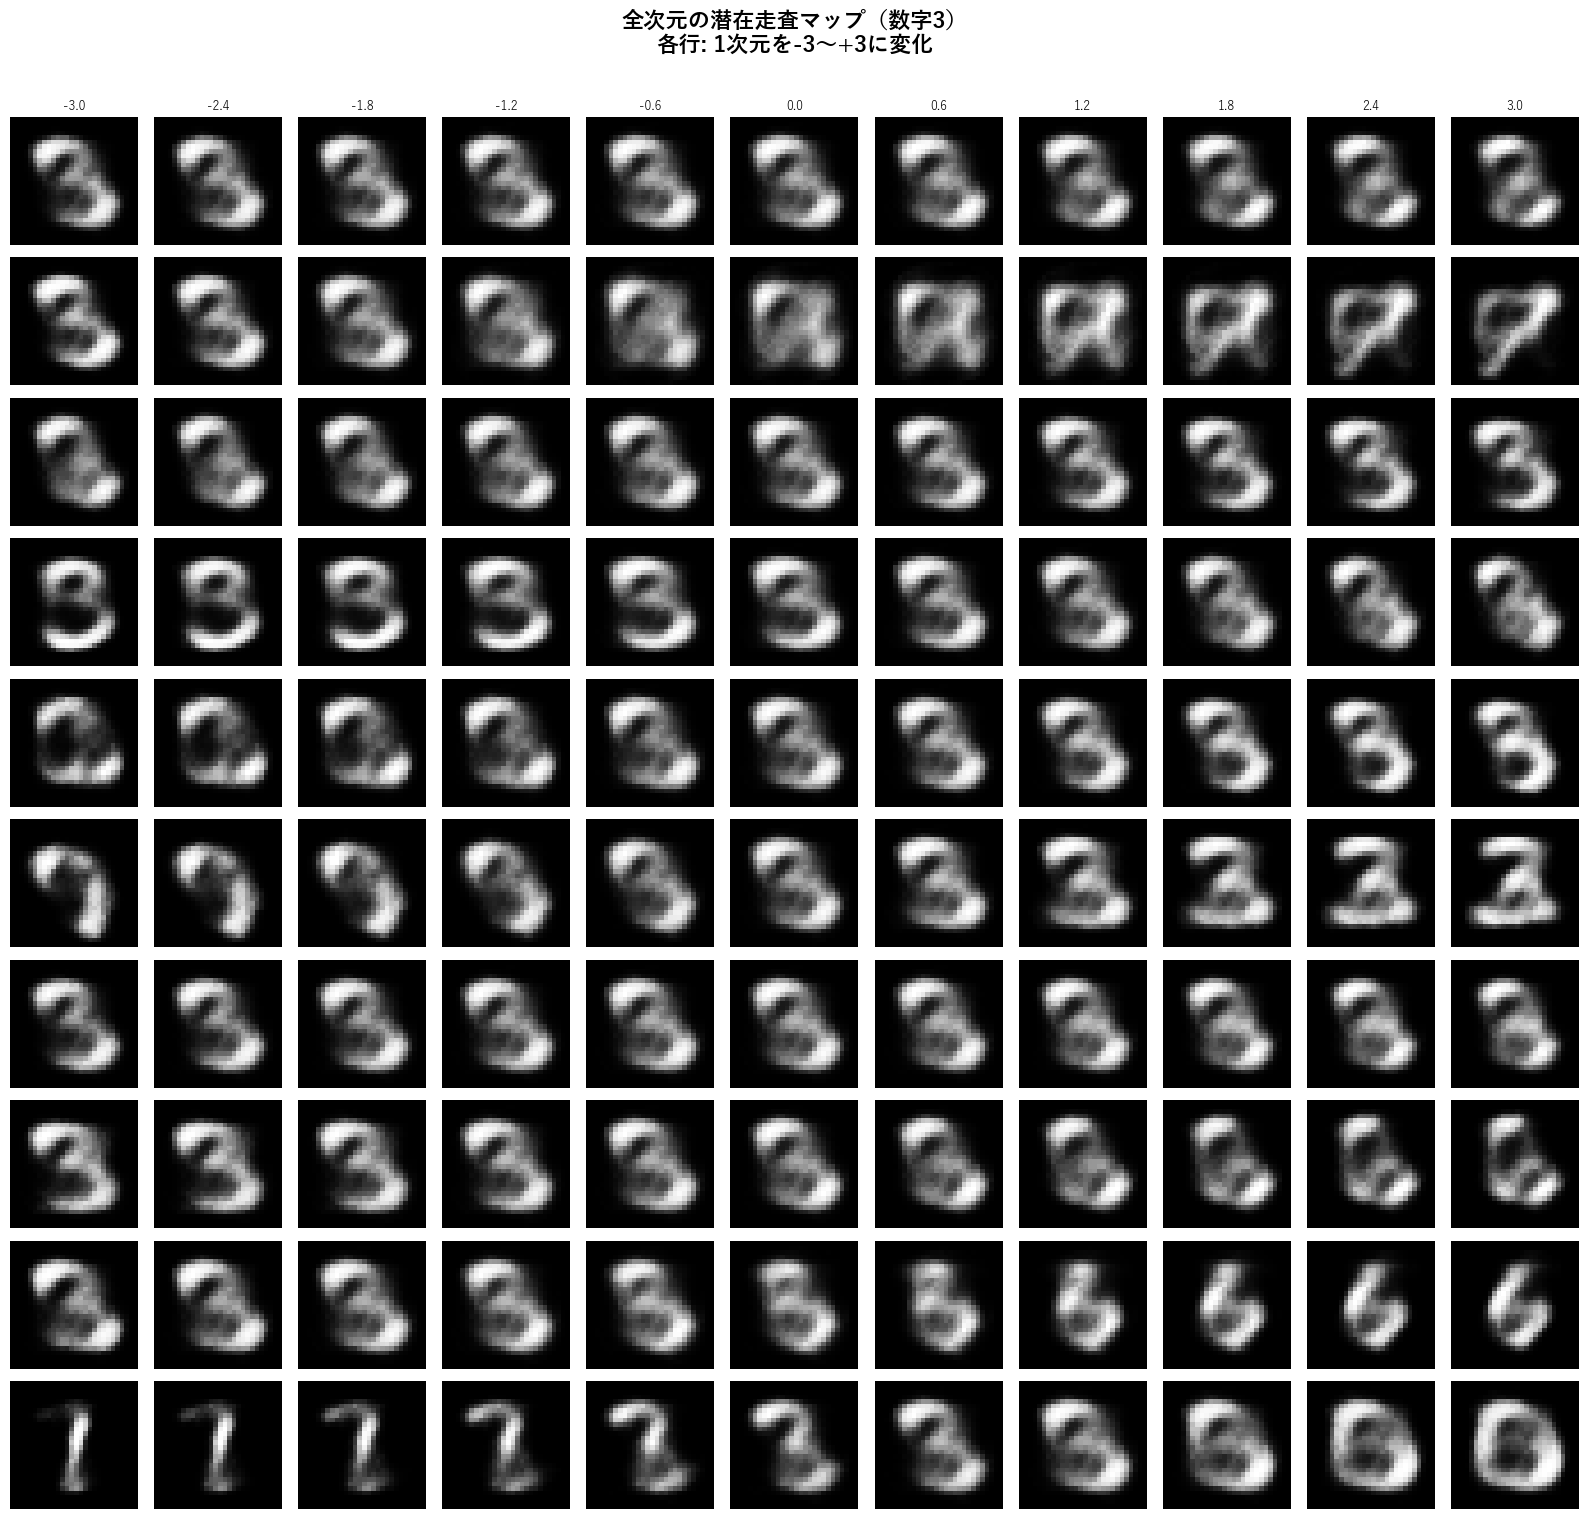

💡 各行を観察して、以下を見つけてください：
   - 大きく変化する次元は？ → その次元は重要な情報を持つ
   - ほとんど変化しない次元は？ → KL正則化で潰されている可能性
   - 1つの次元で複数の属性が同時に変わる？ → もつれ（entanglement）


In [4]:
# ============================================================
# 全次元の走査マップ（10次元 × 11ステップ）
# ============================================================

n_dims = model.latent_dim if hasattr(model, 'latent_dim') else 10
n_steps = 11
z_range = np.linspace(-3, 3, n_steps)

# 数字3のサンプル
base_idx = digit_indices[3][0]
z_base = all_z[base_idx].copy()

fig, axes = plt.subplots(n_dims, n_steps, figsize=(16, n_dims * 1.5))

for dim in range(n_dims):
    for i, val in enumerate(z_range):
        z_mod = z_base.copy()
        z_mod[dim] = val
        img = decode_z(z_mod)
        axes[dim, i].imshow(img, cmap='gray')
        axes[dim, i].axis('off')
        if i == 0:
            axes[dim, i].set_ylabel(f'z{dim}', fontsize=11, rotation=0, labelpad=20)
        if dim == 0:
            axes[dim, i].set_title(f'{val:.1f}', fontsize=9)

fig.suptitle('全次元の潜在走査マップ（数字3）\n各行: 1次元を-3〜+3に変化',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_303_02_full_traversal_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 各行を観察して、以下を見つけてください：")
print("   - 大きく変化する次元は？ → その次元は重要な情報を持つ")
print("   - ほとんど変化しない次元は？ → KL正則化で潰されている可能性")
print("   - 1つの次元で複数の属性が同時に変わる？ → もつれ（entanglement）")

最も変化が大きい次元 Top3: z9, z5, z1


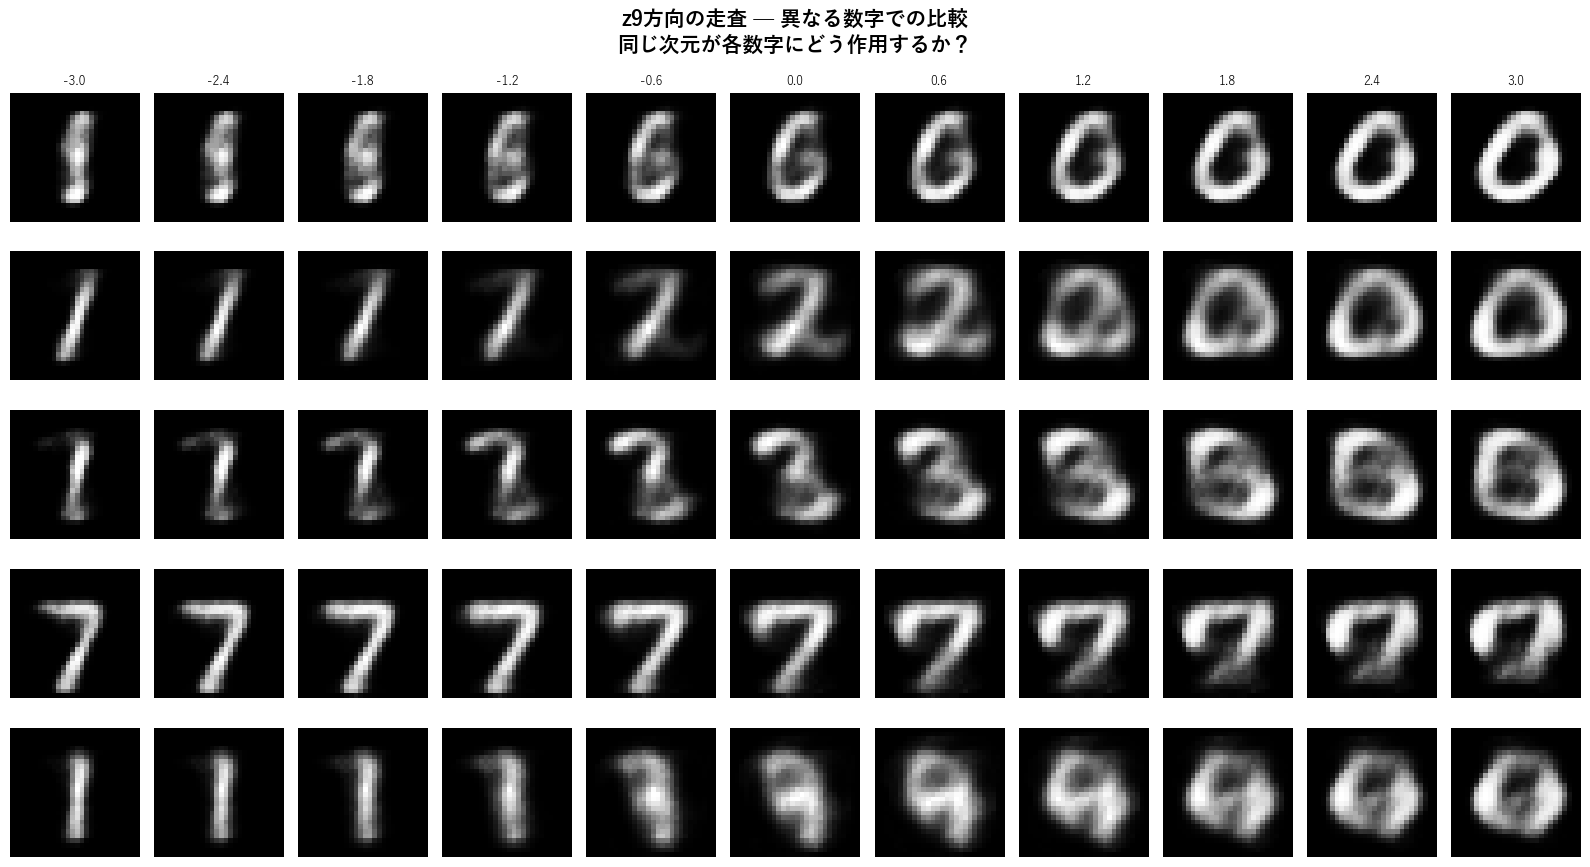

💡 z9は各数字に対して一貫した変化を与えているか？
   一貫していれば → disentangledな次元（良い）
   数字ごとに違う → entangledな次元（次元が複数の属性を担当）


In [5]:
# ============================================================
# 異なる数字での走査比較
# 同じ次元が数字ごとにどう作用するか
# ============================================================

# 最も変化が大きい次元を自動検出
dim_variance = []
for dim in range(n_dims):
    images_traversal = []
    for val in z_range:
        z_mod = z_base.copy()
        z_mod[dim] = val
        images_traversal.append(decode_z(z_mod).flatten())
    images_arr = np.array(images_traversal)
    dim_variance.append(np.var(images_arr, axis=0).mean())

top_dims = np.argsort(dim_variance)[::-1][:3]
print(f"最も変化が大きい次元 Top3: z{top_dims[0]}, z{top_dims[1]}, z{top_dims[2]}")

# Top3次元を5つの数字で比較
digits_show = [0, 1, 3, 7, 9]
fig, axes = plt.subplots(len(digits_show), n_steps, figsize=(16, len(digits_show) * 1.8))

selected_dim = top_dims[0]

for row, digit in enumerate(digits_show):
    idx = digit_indices[digit][0]
    z_base_d = all_z[idx].copy()

    for col, val in enumerate(z_range):
        z_mod = z_base_d.copy()
        z_mod[selected_dim] = val
        img = decode_z(z_mod)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f'{digit}', fontsize=14, rotation=0, labelpad=20)
        if row == 0:
            axes[row, col].set_title(f'{val:.1f}', fontsize=9)

fig.suptitle(f'z{selected_dim}方向の走査 — 異なる数字での比較\n同じ次元が各数字にどう作用するか？',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_303_03_cross_digit_traversal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💡 z{selected_dim}は各数字に対して一貫した変化を与えているか？")
print("   一貫していれば → disentangledな次元（良い）")
print("   数字ごとに違う → entangledな次元（次元が複数の属性を担当）")

---

## 3. GIFアニメーション生成

潜在走査を**アニメーション**にすると、変化がより直感的に分かります。

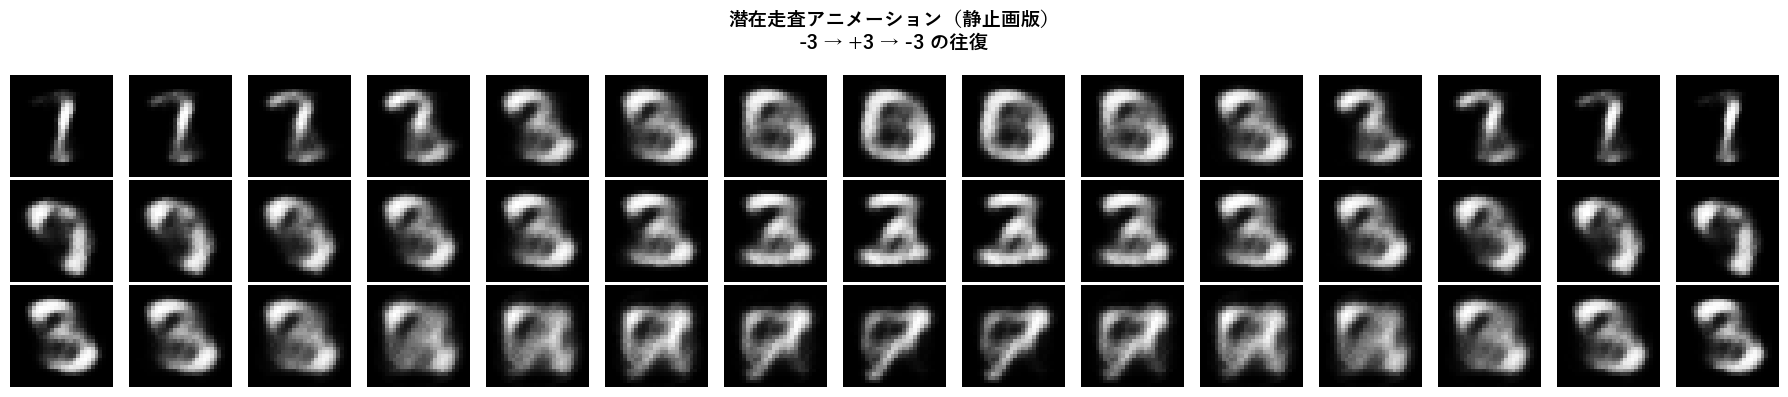

💡 各行が1つの次元の「往復走査」
   スムーズな変化 → 連続的な潜在空間の証拠


In [6]:
# ============================================================
# 潜在走査のアニメーション生成
# ============================================================

def create_traversal_animation(z_base, dim, n_frames=30, z_min=-3, z_max=3):
    """指定した次元の走査アニメーションを生成"""
    z_values = np.concatenate([
        np.linspace(z_min, z_max, n_frames // 2),
        np.linspace(z_max, z_min, n_frames // 2)
    ])

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    frames = []

    for val in z_values:
        z_mod = z_base.copy()
        z_mod[dim] = val
        img = decode_z(z_mod)
        im = ax.imshow(img, cmap='gray', animated=True)
        title = ax.text(0.5, 1.02, f'z{dim} = {val:.2f}',
                       transform=ax.transAxes, ha='center', fontsize=12)
        ax.axis('off')
        frames.append([im, title])

    anim = animation.ArtistAnimation(fig, frames, interval=80, blit=True)
    return anim, fig

# 数字3でTop3次元のアニメーション
base_idx = digit_indices[3][0]
z_base = all_z[base_idx].copy()

# 静止画のストリップとして表示（アニメの代替）
fig, axes = plt.subplots(3, 15, figsize=(18, 4))
n_strip = 15
z_vals = np.concatenate([np.linspace(-3, 3, 8), np.linspace(3, -3, 7)])

for row, dim in enumerate(top_dims[:3]):
    for col, val in enumerate(z_vals):
        z_mod = z_base.copy()
        z_mod[dim] = val
        img = decode_z(z_mod)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'z{dim}', fontsize=12, rotation=0, labelpad=20)

fig.suptitle('潜在走査アニメーション（静止画版）\n-3 → +3 → -3 の往復',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_303_04_traversal_strips.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 各行が1つの次元の「往復走査」")
print("   スムーズな変化 → 連続的な潜在空間の証拠")

✅ GIF保存完了: fig_303_05_traversal_animation.gif


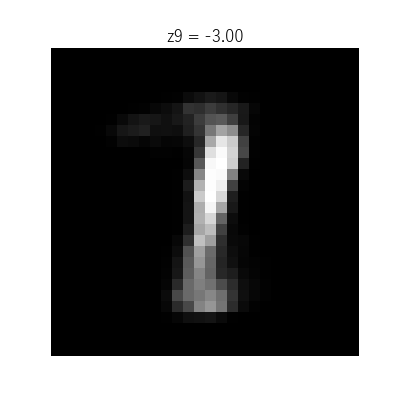

In [7]:
# ============================================================
# GIFアニメーションの保存（Jupyter上で表示）
# ============================================================

# 最も面白い次元でアニメーション生成
dim_to_animate = top_dims[0]
base_idx = digit_indices[3][0]
z_base_anim = all_z[base_idx].copy()

anim, fig_anim = create_traversal_animation(z_base_anim, dim_to_animate, n_frames=40)

# GIFとして保存
gif_path = 'fig_303_05_traversal_animation.gif'
try:
    anim.save(gif_path, writer='pillow', fps=12)
    plt.close(fig_anim)
    print(f"✅ GIF保存完了: {gif_path}")

    # Jupyter上で表示
    display(IPImage(filename=gif_path))
except Exception as e:
    plt.close(fig_anim)
    print(f"⚠️ GIF保存をスキップ: {e}")
    print("   Pillowがインストールされていない可能性があります")
    print("   静止画版（上の図）で代替してください")

---

## 4. もつれ（Entanglement）の問題

### 🤔 通常のVAEの潜在空間は「もつれている」

潜在走査で観察すると、**1つの次元を動かしたときに複数の属性が同時に変わる**ことがよくあります。

```
  もつれた潜在空間（標準VAE）          解きほぐされた潜在空間（理想）
  ──────────────────────               ──────────────────────────
  z₁を変えると → 太さ+傾きが同時に変化    z₁を変えると → 太さだけ変化
  z₂を変えると → 丸み+大きさが同時に変化   z₂を変えると → 傾きだけ変化
```

これが**Disentanglement問題**であり、次章（304）で詳しく学びます。

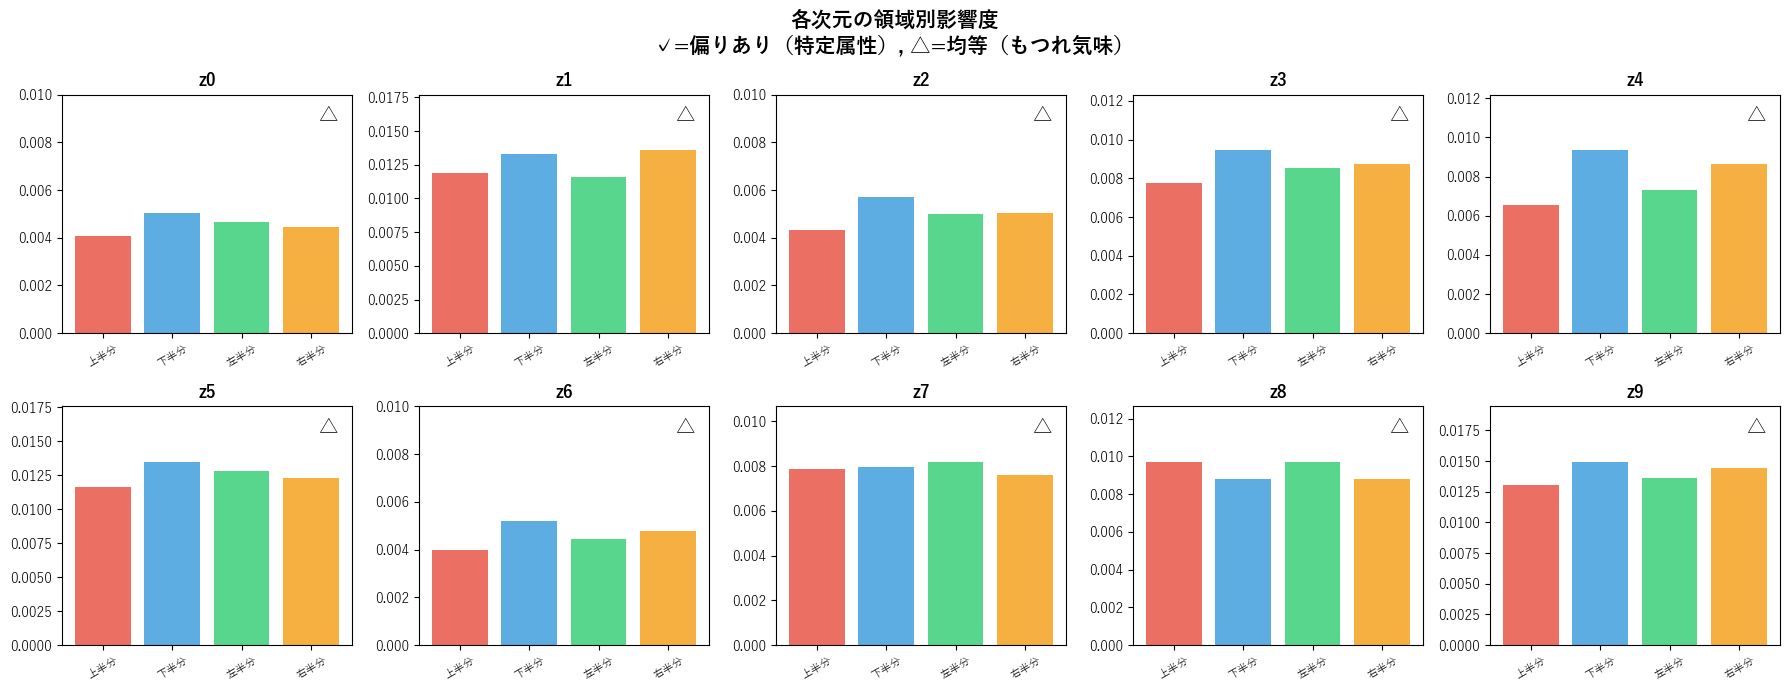

💡 特定の領域だけに強く影響 → より解きほぐされた次元
   全領域に均等に影響 → もつれている次元
   → 次章（304）でβ-VAEを使った解きほぐしを学びます


In [8]:
# ============================================================
# もつれ度の定量的分析
# 各次元がどれだけ「複数の属性」に影響するか
# ============================================================

# 各次元の走査における変化量を分析
# 画像の異なる領域（上半分/下半分/左半分/右半分）への影響を測定

def measure_regional_change(z_base, dim, z_range):
    """指定次元を走査したときの各領域の変化量"""
    images = []
    for val in z_range:
        z_mod = z_base.copy()
        z_mod[dim] = val
        images.append(decode_z(z_mod))

    images = np.array(images)  # (n_steps, 28, 28)

    # 連続するフレーム間の差分の絶対値
    diffs = np.abs(np.diff(images, axis=0))

    # 4つの領域に分割
    regions = {
        '上半分': diffs[:, :14, :].mean(),
        '下半分': diffs[:, 14:, :].mean(),
        '左半分': diffs[:, :, :14].mean(),
        '右半分': diffs[:, :, 14:].mean(),
    }
    return regions

z_range_analysis = np.linspace(-3, 3, 20)
base_idx = digit_indices[3][0]
z_base = all_z[base_idx].copy()

# 各次元の領域別影響度
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
region_names = ['上半分', '下半分', '左半分', '右半分']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for dim in range(n_dims):
    row, col = dim // 5, dim % 5
    regions = measure_regional_change(z_base, dim, z_range_analysis)
    values = [regions[r] for r in region_names]

    bars = axes[row, col].bar(region_names, values, color=colors, alpha=0.8)
    axes[row, col].set_title(f'z{dim}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylim(0, max(max(values) * 1.3, 0.01))
    axes[row, col].tick_params(axis='x', rotation=30, labelsize=8)

    # 均等に影響 = もつれている vs 偏り = 特定属性
    balance = np.std(values) / (np.mean(values) + 1e-8)
    marker = '✓' if balance > 1.0 else '△'
    axes[row, col].text(0.95, 0.95, marker, transform=axes[row, col].transAxes,
                       ha='right', va='top', fontsize=14)

fig.suptitle('各次元の領域別影響度\n✓=偏りあり（特定属性）, △=均等（もつれ気味）',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_303_06_entanglement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 特定の領域だけに強く影響 → より解きほぐされた次元")
print("   全領域に均等に影響 → もつれている次元")
print("   → 次章（304）でβ-VAEを使った解きほぐしを学びます")

---

## まとめ

### 🎯 このノートブックで学んだこと

**潜在走査の基本**
- ✓ 1次元ずつ動かして各次元の意味を発見する手法を習得
- ✓ 全次元の走査マップで潜在空間の全体像を把握できる

**異なるサンプルでの比較**
- ✓ 同じ次元が異なる数字に対して一貫した変化を与えるか確認
- ✓ 一貫していればdisentangled、そうでなければentangled

**アニメーション化**
- ✓ GIFアニメーションで走査結果を直感的に観察

**もつれの問題**
- ✓ 標準的なVAEの潜在空間は完全にはdisentangleされていない
- ✓ 領域別影響分析で定量的にもつれ度を評価できる

### 📊 チートシート

| 用語 | 意味 |
|------|------|
| 潜在走査 | 1次元を変化させ他を固定する分析手法 |
| Disentangled | 各次元が独立した1つの属性を制御 |
| Entangled | 1つの次元が複数の属性に影響 |
| 走査マップ | 全次元の走査結果を行列状に表示 |

### ⚠️ よくある間違い

❌ 「走査で変化が小さい次元は不要」
✅ その次元はKL正則化で N(0,1) に近づいているだけかもしれない。モデルの構造上は意味がある

❌ 「各次元は必ず1つの属性に対応する」
✅ 標準VAEでは保証されない。β-VAE等の手法が必要

### ✅ 学習チェックリスト

- [ ] 潜在走査の手順を説明できるか？
- [ ] 走査マップから「重要な次元」を特定できるか？
- [ ] entanglementの問題を例を挙げて説明できるか？

---

**次のステップ**: ノートブック304「解きほぐされた表現」で、β-VAEを使って各次元が独立した属性を持つ潜在空間を学習する方法を学びます！

---

## 🎓 自己評価クイズ

### Q1: 潜在走査でz₃を-3から+3に動かしたとき、数字の太さと傾きが同時に変わった。この現象は何と呼ばれるか？

<details>
<summary>💡 答えを見る</summary>

**答え**: Entanglement（もつれ）

z₃が太さと傾きの両方の情報を担当しているため、一方だけを独立に変えることができません。
理想的にはz₃=太さ、z₄=傾き のように分離（disentangle）されるべきです。

</details>

---

### Q2: 走査マップで、ある次元を動かしてもほとんど画像が変わらない場合、何が起きているか？

<details>
<summary>💡 答えを見る</summary>

**答え**: KL正則化により、その次元が標準正規分布 N(0,1) に潰されている

VAEのKL項は各次元をN(0,1)に近づけようとします。
必要のない次元は「潰されて」使われなくなります。
これは潜在次元が多すぎる場合によく起きます。

</details>

---

### Q3: 潜在走査とベクトル演算（302章）の違いは？

<details>
<summary>💡 答えを見る</summary>

**答え**: 走査は「座標軸方向」、ベクトル演算は「任意の方向」への移動

潜在走査は z₁, z₂, ... という座標軸に沿った探索。
ベクトル演算は「太さベクトル」のような任意の方向への移動。
座標軸方向と意味的な属性方向が一致していれば（disentangled）、
走査だけで十分ですが、通常のVAEではそうならないため、ベクトル演算も重要です。

</details>